In [276]:
import os
import math
import cv2
import numpy as np
import pandas as pd
from scipy import interpolate, signal
from pathlib import Path
from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, r'C:\Users\nVoke\PycharmProjects\pythonProject1\tools')
from scan import scan_file

from matplotlib import pyplot as plt
%matplotlib inline

'''
    install cv2: pip install opencv-python -i https://pypi.tuna.tsinghua.edu.cn/simple
'''

'\n    install cv2: pip install opencv-python -i https://pypi.tuna.tsinghua.edu.cn/simple\n'

<img src='../image/cell_body.png' style='width: 500px' />

Morphology Features
- Soma area
- Primary dendrite number
- Node number
- Ending number
- Process area
- Total dendritic length
- Mean dendritic length = Total Length / Primary dendrite number

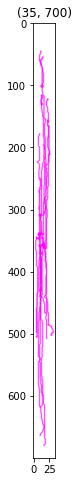

In [277]:
# target_col = [255,0,255] ## magenta
target_col = [233,220,33] ## yellow
# target_col = [0,255,255] ## cyan

fpath = r'G:\Homer_demo\occipital_lobe_1202_slice3_local0\20251130_pv_homer\cell2_pv_demo\remove_background'
file = 'ZY view snapshot.tif'

img = Image.open(fpath+f'\\{file}')
x = np.array(img)
height, width, _ = x.shape

plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.title(f'{img.size}')
plt.show()

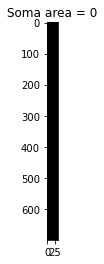

In [ ]:

r, g, b = x[:,:,0], x[:,:,1], x[:,:,2]

soma = np.where((r == 255) & (g == 0) & (b == 0), 255, 0).astype(np.uint8)

soma_area = np.count_nonzero(soma)

plt.imshow(soma, cmap='gray')
plt.title(f'Soma area = {soma_area}')
plt.show()

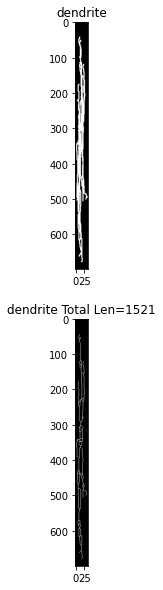

In [ ]:

dend_branch = np.where((r == 255) & (g < 255) & (b == 255), 255, 0).astype(np.uint8)

dend_skeleton = cv2.ximgproc.thinning(dend_branch)

len_dend = np.count_nonzero(dend_skeleton)

# cv2.imwrite(outpath+'\\dendrite.png', dend_skeleton)

plt.figure(figsize=(16, 10))

plt.subplot(222); plt.imshow(dend_branch, cmap='gray'); plt.title('dendrite')

plt.subplot(224); plt.imshow(dend_skeleton, cmap='gray'); plt.title(f'dendrite Total Len={len_dend}')

plt.show()

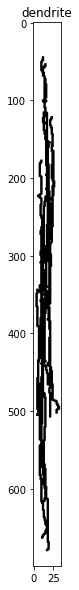

In [280]:
dend_branch = np.where((r == 255) & (g < 255) & (b == 255), 0, 255).astype(np.uint8)

plt.figure(figsize=(16, 10))

plt.imshow(dend_branch, cmap='gray'); plt.title('dendrite')
out_pil = Image.fromarray(dend_branch)
out_pil.save(os.path.join(fpath,f'{file[:2]}_black.png'))

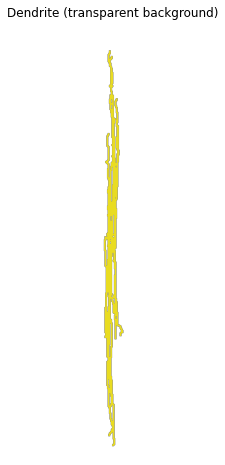

In [ ]:
mask = (r == 255) & (g < 255) & (b == 255)

h, w = r.shape
out_img = np.zeros((h, w, 4), dtype=np.uint8)  # RGBA

out_img[mask, 0:3] = target_col  # RGB
out_img[mask, 3] = 255              # Alpha

plt.figure(figsize=(12, 8))
plt.imshow(out_img)
plt.axis('off')
plt.title('Dendrite (transparent background)')

out_pil = Image.fromarray(out_img)
out_pil.save(os.path.join(fpath,f'{file[:2]}_transparent.png'))

plt.show()